In [13]:
import torch
torch.classes.__path__ = []

import operator
import json
import numpy as np
import yfinance as yf
import sqlite3

from typing import Annotated, Literal
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.sqlite import SqliteSaver

print("imports done")

imports done


In [14]:
class FinancialAgentState(MessagesState):
    query:           str
    retrieved_docs:  Annotated[list[Document], operator.add]
    context:         Annotated[str, operator.add]
    generation:      str
    needs_retrieval: bool

print("state defined")

state defined


In [15]:
class RouteDecision(BaseModel):
    needs_retrieval: bool

In [16]:
embeddings = OllamaEmbeddings(model="nomic-embed-text")

chroma_db = Chroma(
    collection_name="financial_docs",
    embedding_function=embeddings,
    persist_directory="vectorstore/chroma",
)

base_retriever = chroma_db.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 10, "fetch_k": 30, "lambda_mult": 0.7},
)

document_llm   = ChatOllama(model="mistral", temperature=0.3)
generation_llm = ChatOllama(model="mistral", temperature=0)

print(f"DB chunks : {chroma_db._collection.count()}")


DB chunks : 32300


In [17]:
hyde_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a financial analyst. Write a short 3-4 sentence "
               "passage that would appear in an official financial report."),
    ("human", "Question: {question}\n\nPassage:")
])

hyde_chain = hyde_prompt | document_llm | StrOutputParser()

def hyde_retrieve(question: str) -> list[Document]:
    hyp_doc = hyde_chain.invoke({"question": question})
    print(f"HyDE: {hyp_doc[:80]}...")
    return base_retriever.invoke(hyp_doc)

# test
results = hyde_retrieve("What is the inflation forecast?")
print(f"HyDE docs: {len(results)}")

HyDE:  Based on current economic indicators and expert analysis, the projected annual ...
HyDE docs: 10


In [18]:
class SubQueries(BaseModel):
    sub_queries: list[str] = Field(..., description="List of sub-queries")


def rag_fusion(question: str, n: int = 3) -> list[Document]:
    # FIXED prompt — forces natural language, not SQL
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You generate search queries for financial documents.
Output ONLY plain English search phrases.
Do NOT generate SQL or code.
Each query must be a short phrase like: 'gold demand trends 2024'"""),
        ("human", "Main question: {question}\nGenerate {n} different search phrases.")
    ])
    chain       = prompt | document_llm.with_structured_output(SubQueries)
    sub_queries = chain.invoke({"question": question, "n": n}).sub_queries
    print(f"Sub-queries: {sub_queries}")

    all_results = [base_retriever.invoke(q) for q in sub_queries]

    scores = {}
    for results in all_results:
        for rank, doc in enumerate(results, 1):
            key         = doc.page_content
            prev        = scores.get(key, (0, doc))
            scores[key] = (prev[0] + 1 / (rank + 60), doc)

    return [doc for _, doc in sorted(scores.values(), key=lambda x: x[0], reverse=True)][:5]


# test
results = rag_fusion("gold demand outlook")
print(f"Fusion docs: {len(results)}")
print(f"Sample: {results[0].page_content[:150]}")

Sub-queries: ['Gold demand forecast for the future', 'Projected gold demand trends', 'Upcoming gold demand outlook analysis']
Fusion docs: 5
Sample: C. Bars show recycled gold supply in metric tons. Last observation is 2025.
D. Blue bars show the World Bank Group’s baseline forecast for 2026. Red m


In [19]:
def advanced_retrieve(question: str) -> list[Document]:
    hyde_docs   = hyde_retrieve(question)
    fusion_docs = rag_fusion(question)

    seen, unique = set(), []
    for doc in hyde_docs + fusion_docs:
        key = doc.page_content[:100]
        if key not in seen:
            seen.add(key)
            unique.append(doc)

    return unique[:5]


# test
final = advanced_retrieve("What is the inflation rate forecast?")
print(f"Final docs: {len(final)}")
for i, doc in enumerate(final, 1):
    print(f"[{i}] {doc.metadata.get('source')} | page {doc.metadata.get('page')}")
    print(doc.page_content[:150])
    print()

HyDE:  Based on our economic projections, we anticipate an annual inflation rate of 2....
Sub-queries: ['Inflation rate forecast for the year 2024', 'Projected inflation rates in 2024', 'Expected inflation trends for next year']
Final docs: 5
[1] OECD Economic Outlook.pdf | page 121
from the second half of the year, supported by contained demand pressures, tight monetary policy and 
persistent fiscal discipline. Average headline i

[2] OECD Economic Outlook.pdf | page 194
is projected to slow as inflation reduces households ’ purchasing power. As some of these headwinds 
recede in FY2027-28, growth is expected to recove

[3] OECD Economic Outlook.pdf | page 245
driven mainly by temporary supply shocks. Should inflation prove more persistent, a tighter policy stance 
would be required to ensure convergence tow

[4] OECD Economic Outlook, Volume 2025.pdf | page 179
headline inflation is projected to gradually converge towards the 4% target. Risks are broadly ba lanced. 
Bilateral negotia

In [20]:
@tool(response_format="content_and_artifact")
def search_financial_docs(query: str):
    """
    Search internal financial documents (RBI, IMF, Gold, Oil reports).
    Use for: policy data, historical stats, institutional forecasts.
    Do NOT use for live prices or today's news.
    """
    docs    = advanced_retrieve(query)
    context = "\n\n## Document Results\n\n" + "\n\n".join(
        f"[{d.metadata.get('source','?')}, page {d.metadata.get('page','?')}]\n{d.page_content}"
        for d in docs
    )
    return context, docs


@tool(response_format="content_and_artifact")
def get_market_data(ticker: str):
    """
    Get live stock/commodity market data.
    Use for: current price, P/E ratio, market cap, analyst rating.
    Tickers: AAPL, RELIANCE.NS, GC=F=gold, CL=F=oil, ^NSEI=Nifty
    """
    try:
        info = yf.Ticker(ticker).info
        data = {
            "name":           info.get("longName"),
            "price":          info.get("currentPrice") or info.get("regularMarketPrice"),
            "currency":       info.get("currency"),
            "pe_ratio":       info.get("trailingPE"),
            "market_cap":     info.get("marketCap"),
            "52w_high":       info.get("fiftyTwoWeekHigh"),
            "52w_low":        info.get("fiftyTwoWeekLow"),
            "analyst_rating": info.get("recommendationKey"),
        }
        content = f"\n\n## Market Data\n\n{json.dumps(data, indent=2, default=str)}"
        return content, data
    except Exception as e:
        return f"Error: {e}", {}


@tool(response_format="content_and_artifact")
def get_news_sentiment(ticker: str):
    """
    Get recent news headlines and FinBERT sentiment.
    Use for: bullish/bearish mood for any asset.
    Examples: AAPL, gold, HDFC, oil
    """
    try:
        headlines = [
            a["title"] for a in yf.Ticker(ticker).news[:8]
            if a.get("title")
        ]
        if not headlines:
            return f"No news for {ticker}", {}

        from transformers import pipeline as hf_pipeline
        pipe   = hf_pipeline("text-classification",
                              model="ProsusAI/finbert",
                              top_k=1, truncation=True)
        counts = {"positive": 0, "negative": 0, "neutral": 0}
        items  = []

        for h in headlines:
            label = pipe(h)[0][0]["label"].lower()
            counts[label] += 1
            items.append({"headline": h, "sentiment": label})

        total   = len(headlines)
        overall = (
            "BULLISH" if counts["positive"]/total >= 0.6 else
            "BEARISH" if counts["negative"]/total >= 0.6 else
            "NEUTRAL"
        )
        result  = {"overall": overall, "counts": counts, "articles": items}
        content = f"\n\n## News Sentiment\n\n{json.dumps(result, indent=2)}"
        return content, result

    except Exception as e:
        return f"Error: {e}", {}


@tool(response_format="content_and_artifact")
def financial_calculator(calc_type: str, parameters: str):
    """
    Run financial calculations: cagr, sharpe, dcf, compound_interest.
    cagr:     {"start_value":50000, "end_value":120000, "years":8}
    sharpe:   {"returns":[0.05,-0.02,0.08], "risk_free_rate":0.04}
    dcf:      {"fcfs":[100,120,140], "discount_rate":0.10, "terminal_growth":0.03}
    compound: {"principal":100000, "annual_rate":0.08, "years":10, "n":12}
    """
    try:
        p = json.loads(parameters)

        if calc_type == "cagr":
            cagr   = (p["end_value"] / p["start_value"]) ** (1/p["years"]) - 1
            result = {"cagr_pct": round(cagr * 100, 2)}

        elif calc_type == "sharpe":
            r      = np.array(p["returns"])
            sr     = (np.mean(r) - p.get("risk_free_rate", 0.04)) / np.std(r, ddof=1)
            result = {"sharpe_ratio":   round(float(sr), 4),
                      "interpretation": "Excellent" if sr>1 else "Good" if sr>0.5 else "Poor"}

        elif calc_type == "dcf":
            r, g   = p.get("discount_rate", 0.10), p.get("terminal_growth", 0.03)
            pvs    = [f/(1+r)**t for t,f in enumerate(p["fcfs"], 1)]
            tv     = p["fcfs"][-1] * (1+g) / (r-g)
            result = {"pv_cashflows":    round(sum(pvs), 2),
                      "terminal_value":  round(tv, 2),
                      "intrinsic_value": round(sum(pvs) + tv/(1+r)**len(p["fcfs"]), 2)}

        elif calc_type == "compound_interest":
            P,r,n,t = p["principal"], p["annual_rate"], p.get("n",12), p["years"]
            A       = P * (1 + r/n) ** (n*t)
            result  = {"future_value":    round(A, 2),
                       "interest_earned": round(A-P, 2)}

        else:
            return f"Unknown: {calc_type}", {}

        content = f"\n\n## Calculation\n\n{json.dumps(result, indent=2)}"
        return content, result

    except Exception as e:
        return f"Error: {e}", {}


ALL_TOOLS = [
    search_financial_docs,
    get_market_data,
    get_news_sentiment,
    financial_calculator,
    
]

print(f"{len(ALL_TOOLS)} tools ready:")
for t in ALL_TOOLS:
    print(f" - {t.name}")

4 tools ready:
 - search_financial_docs
 - get_market_data
 - get_news_sentiment
 - financial_calculator


In [21]:
ROUTE_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a financial query router.
Decide if the query needs the agent with tools.

needs_retrieval = True for ALL of these:
  - current stock price, live market data
  - news sentiment, recent headlines
  - financial calculations (CAGR, Sharpe, DCF)
  - explain a financial concept
  - ANY question needing real-time or computed data
  - questions about specific companies or assets

needs_retrieval = False ONLY for:
  - pure general knowledge with no financial data needed
  - e.g. "What is the capital of France?"

When in doubt → return True"""),
    ("human", "Query: {query}")
])

route_chain = ROUTE_PROMPT | generate_llm.with_structured_output(RouteDecision)

print("route chain updated")


NameError: name 'generate_llm' is not defined

In [ ]:
SYSTEM_PROMPT = """You are an expert AI Financial Analyst assistant.

You have 4 tools. Use them as follows:

1. search_financial_docs
   → RBI/IMF/Gold/Oil reports, policy data, historical stats

2. get_market_data
   → Live price, P/E ratio, market cap, analyst rating
   → Tickers: AAPL, RELIANCE.NS, GC=F, CL=F, ^NSEI

3. get_news_sentiment
   → Recent news, bullish/bearish market mood

4. financial_calculator
   → DCF, Sharpe ratio, CAGR, compound interest



RULES:
- Always use tools for data, never guess numbers
- Cite document sources: [filename, page]
- For complex questions, call multiple tools in sequence
- Add risk disclaimer for investment advice
- If user seems unfamiliar with a term, call explain_concept
"""

print("System prompt ready")
agent_llm_with_tools = agent_llm.bind_tools(ALL_TOOLS)

GEN_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You are a financial analyst. Answer using only the context. "
               "Cite sources. Add risk disclaimer for investment advice."),
    ("human", "Context:\n{context}\n\nQuestion: {query}")
])

gen_chain = GEN_PROMPT | llm | StrOutputParser()

print("prompts ready")

System prompt ready
prompts ready


In [ ]:
# ── Node 1: route_question ─────────────────────────────────────
def route_question(state: FinancialAgentState) -> dict:
    decision = route_chain.invoke({"query": state["query"]})
    print(f"route_question → needs_retrieval: {decision.needs_retrieval}")
    return {"needs_retrieval": decision.needs_retrieval}


# route_question branches:
#   True  → agent (needs document retrieval)
#   False → generate (answer directly, no retrieval)
def route_edge(state: FinancialAgentState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"


# ── Node 2: agent ──────────────────────────────────────────────
def agent(state: FinancialAgentState) -> dict:
    msgs = state["messages"]
    if not any(isinstance(m, SystemMessage) for m in msgs):
        msgs = [SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(content=state["query"])]
    response = agent_llm_with_tools.invoke(msgs)
    return {"messages": [response]}


# agent branches:
#   has tool_calls → tools
#   no tool_calls  → collect_tool_output
def should_continue(state: FinancialAgentState) -> Literal["tools", "collect_tool_output"]:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return "collect_tool_output"


# ── Node 3: collect_tool_output ────────────────────────────────
def collect_tool_output(state: FinancialAgentState) -> dict:
    context = "\n\n".join(
        msg.content
        for msg in state["messages"]
        if isinstance(msg, ToolMessage)
    )
    if not context:
        context = "No tool output."
    return {"context": context}


# ── Node 4: generate ───────────────────────────────────────────
def generate(state: FinancialAgentState) -> dict:
    context = state.get("context", "Answer from general knowledge.")
    return {"generation": gen_chain.invoke({
        "context": context,
        "query":   state["query"],
    })}

print("nodes defined")

nodes defined


agent compiled


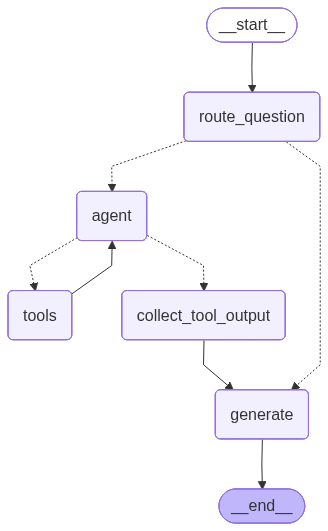

In [ ]:
graph = StateGraph(FinancialAgentState)

# add nodes
graph.add_node("route_question",route_question)
graph.add_node("agent",agent)
graph.add_node("tools",ToolNode(ALL_TOOLS))
graph.add_node("collect_tool_output", collect_tool_output)
graph.add_node("generate",generate)

# add edges
graph.add_edge(START, "route_question")
graph.add_conditional_edges("route_question", route_edge)
graph.add_conditional_edges("agent", should_continue)
graph.add_edge("tools","agent")
graph.add_edge("collect_tool_output", "generate")
graph.add_edge("generate",END)

app = graph.compile()
print("agent compiled")
app

In [ ]:
result = app.invoke({
    "query":          "What does the RBI report say about inflation?",
    "messages":       [HumanMessage(content="What does the RBI report say about inflation?")],
    "retrieved_docs": [],
    "context":        "",
})

print(f"needs_retrieval : {result['needs_retrieval']}")
print(f"\nAnswer:\n{result['generation']}")

route_question → needs_retrieval: False
needs_retrieval : False

Answer:
Risk Disclaimer: Please note that this is not personalized investment advice and should not be relied upon as such. The information provided is based on publicly available data and may not reflect current market conditions.

According to recent reports, the Reserve Bank of India (RBI) has stated that inflation remains a concern in the country [1]. The RBI's Monetary Policy Committee (MPC) meeting, which concluded in June 2023, expressed concerns about rising inflation rates, citing factors such as increased food prices and higher-than-expected wage growth [2].

In its bi-monthly policy review, the RBI mentioned that the overall price indices for urban areas have risen by 5.8% year-over-year (YoY), while the farm prices index has grown at a rate of 12.4% YoY [3]. The central bank also noted that inflationary pressures are likely to continue in the short term, driven by factors such as global commodity price increas

In [ ]:
result = app.invoke({
    "query":          "What is the current stock price of Apple IN NASDAQ ?",
    "messages":       [HumanMessage(content="What is the current stock price of Apple IN NASDAQ ?")],
    "retrieved_docs": [],
    "context":        "",
})

print(f"needs_retrieval : {result['needs_retrieval']}")
print(f"\nAnswer:\n{result['generation']}")

route_question → needs_retrieval: False
needs_retrieval : False

Answer:
I'm not capable of providing real-time market data or current stock prices.

However, I can suggest some ways for you to find the current stock price of AAPL (Apple Inc.):

1. Check online financial portals such as Yahoo Finance, Google Finance, or Bloomberg.
2. Visit Apple's official investor relations website to access their stock information.
3. Use a financial news website or app, such as CNBC or The Wall Street Journal.

Please note that stock prices can fluctuate rapidly and may be affected by various market and economic factors.

Risk Disclaimer: Investing in the stock market involves risk, including the potential loss of principal. Past performance is not a guarantee of future results. It's essential to conduct thorough research, consider your investment goals and risk tolerance, and consult with a financial advisor before making any investment decisions.


In [ ]:
! pip install langgraph-checkpoint-sqlite

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

conn   = sqlite3.connect("memory.db", check_same_thread=False)
memory = SqliteSaver(conn)

print("SQLite memory ready")
print("File saved: memory.db")

SQLite memory ready
File saved: memory.db


In [ ]:
app = graph.compile(checkpointer=memory)

print("agent compiled with persistence")
app

NameError: name 'graph' is not defined

In [ ]:
config = {"configurable": {"thread_id": "bipasha_1"}}

result = app.invoke(
    {
        "query":          "What is the current stock price of Apple from YahooFinance?",
        "messages":       [HumanMessage(content="What is the current stock price of Apple from YahooFinance?")],
        "retrieved_docs": [],
        "context":        "", 
    },
    config=config,
)

print(f"needs_retrieval : {result['needs_retrieval']}")
print(f"\nAnswer:\n{result['generation']}")

NameError: name 'app' is not defined